# Основы статистики. Часть II

#### конспект лекций

Автор лекций: **святой Анатолий Карпов**

Конспектировал: **отрок Михаил Курочкин**
  - telegram: @mikhail_kurochkin
  - instagram: [mikhail_k17](https://www.instagram.com/mikhail_k17/) *если хотите вообще от души поблагодарить - подписка/лайк :)*


<img src='img/Saint_Karpov.png'>

<hr>

## Содержание
* ~такой текст~, значит, что это ещё не законспектированно

### Часть 1 Анализ номинативных данных

 - [~Постановка задачи~](#Постановка-задачи)
 - [~Расстояние Пирсона~](#Расстояние-Пирсона)
 - [Распределение Хи-квадрат Пирсона](#Распределение-Хи-квадрат-Пирсона)
 - [Расчет p-уровня значимости](#Расчет-p-уровня-значимости)
 - [~Анализ таблиц сопряженности~](#Анализ-таблиц-сопряженности)
 - [~Точный критерий Фишера~](#Точный-критерий-Фишера)
 - [](#)
 - [](#)
 - [](#)


### Часть 2 Логистическая регрессия и непараметрические методы 

 - [Логистическая регрессия](#Логистическая-регрессия)
     - [Постановка задачи](#Постановка-задачи)
 - [Модель без предикторов. Intercept only model](#Модель-без-предикторов.-Intercept-only-model)
 - [Модель с одним номинативным предиктором](#Модель-с-одним-номинативным-предиктором)
 - [~Модель с двумя номинативными предикторами~](#Модель-с-двумя-номинативными-предикторами)
 - [~Взаимодействие номинативных предикторов~](#Взаимодействие-номинативных-предикторов)
 - [~Когда нужно использовать непараметрические методы и почему?~](#Когда-нужно-использовать-непараметрические-методы-и-почему?)
 - [~Непараметрические методы. Продолжение.~](#Непараметрические-методы.-Продолжение.)
 - [](#)
 - [](#)
 - [](#)

### Часть 3 Кластерный анализ и метод главных компонент

 - [Кластерный анализ методом **k-средних**](#Кластерный-анализ-методом-k-средних)
 - [Может ли кластерный анализ "ошибаться"?](#Может-ли-кластерный-анализ-ошибаться?)
 - [Как определить оптимальное число кластеров?](#Как-определить-оптимальное-число-кластеров?)
 - [~**Иерархическая кластеризация**~](#Иерархическая-кластеризация)
 - [~Введение в метод анализа главных компонент~](#Введение-в-метод-анализа-главных-компонент)
 - [](#)
 - [](#)
 - [](#)

In [1]:
import warnings
warnings.filterwarnings('ignore')

<img src='img/Tests.jpg'>

<img src='img/Untitled Diagram.jpg'>

<hr>

# Часть 1 Анализ номинативных данных

## Постановка задачи

**Первая задача**, которую мы научимся решать, это проверять гипотезу о том, насколько значимым, с точки зрения статистики, явяются отклонения наблюдаемых и ожидаемых частот некоторого номинативного признака.

**Вторая** позволит выявить взаимосвязь двух номинативных переменных, а также проанализировать взаимосвязь двух переменных (насколько она статистически значима).

**Третья задача** первой недели - разбор логистической регрессии (ЗП - номинативная переменная с двумя градациями).

Для решения этих задач мы должны познакомиться с тремя понятиями:
1. Расстояние хи-квадрат,
2. распределение хи-квадрат,
3. критерий хи-квадрат Пирсона.

Флуктуа́ция — любое случайное отклонение какой-либо величины. 

## Расстояние Пирсона

**Пример**

Мы кидали монетку 60 раз. Можно сказать, что результат броска - номинативная переменная с двумя градациями.

выпало:

O (observed): решка = 20; орел = 40

E (expected): решка = 30; орел = 30


H0: P_орла = 0.5

 Н1: Р_орла != 0.5

- То есть сначала мы расчитываем ожидаемые (Е) значения.

- Далее мы смотрим, есть ли расходнения между эмпирическими и ожидаемыми данными.

- Далее думаем: "Ммм, а если бы нулевая гипотеза была верна, и мы бесконечно долго бы повторяли наш эксперимент, то как бы вела некоторая интересующая нас статистика?"

Как же охарактеризовать степень расхождения между ожидаемыми и наблюдаемыми значениями? Желательно получить один показатель, который мы можем проинтерпритировать.

<img src='img/Screenshot from 2023-09-09 22-50-40.png' width=500>

$$ \chi^2 = \sum_{i=1}^n{\frac{(observed_i - expected_i)^2}{expected_i}} = \sum_{i=1}^n{\frac{(O_i - E_i)^2}{E_i}}, $$

где $ n $ - количество "ячеек". То есть суммирование идет по количеству ячеек. В случае в монеткой таких ячейки две.

Возвращаясь к примеру с монеткой: $ \chi^2 = \frac{(20-30)^2}{30} + \frac{(40-30)^2}{30} = 6.7 $

**пример**

Монах Грегор Иоганн выращивал горох трех цветов (бедняга надеялся, что это поможет ему сделать важное открытие).  
В одном из опытов эмпирическое распределение частот некоторого цвета гороха приняло следующий вид:

18,55,27

Чему будут равны ожидаемые значения частот, если предполагаемое теоретическое распределение имеет следующий вид:

1:2:1

**ответ**: 25, 50, 25

**пример**

Эмпирическое распределение частот некоторого номинативного признака с тремя градациями приняло вид
18,55,27. Предполагаемое теоретическое распределение — 1:2:1.

Рассчитайте расстояние хи-квадрат и введите получившееся значение с точностью хотя бы до одной цифры после запятой.

In [1]:
(25 - 18) ** 2 / 25 + (55 - 50) ** 2 / 50 + (27 - 25) ** 2 / 25

2.62

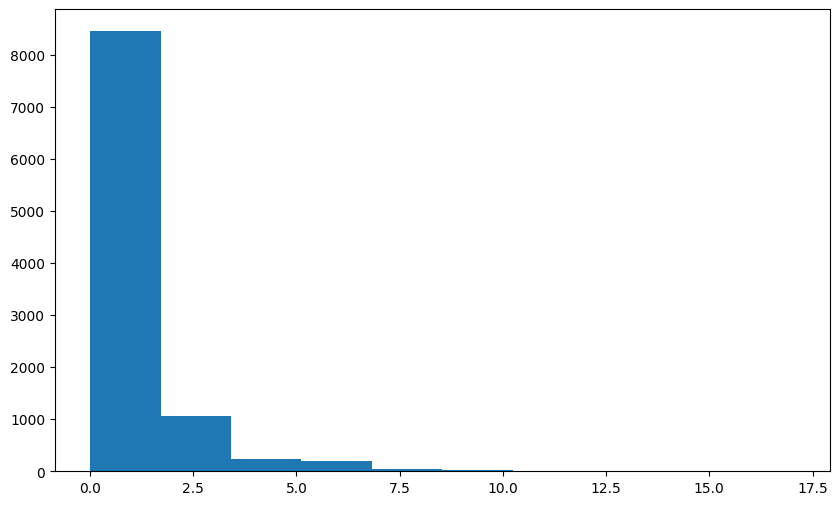

In [6]:
"Распределение Хи-квадрат Пирсона"

import random
import matplotlib.pyplot as plt

ax = plt.subplot(111)
ax.figure.set_size_inches(w=10, h=6)
x = []
for i in range(10000):
    heads = []
    for i in range(60):
        heads.append(random.randint(0, 1))
    x.append((heads.count(0) - 30) ** 2 / 30 + (heads.count(1) - 30) ** 2 / 30)
plt.hist(x)
plt.show()

In [15]:
import plotly.express as px
import random

n = 6 # количество градаций номинативной переменной (количество граней на игральной кости)
N = 100000 # количество выборок (количество измерений расстояний хи-квадрат)
L = 600 # размер одной выборки (сколько раз кидаем кость)
chi_squared = []
for i in range(N):
    result = []
    for j in range(L):
        result.append(random.randint(1, n))
    chi_squared.append(
        sum([(result.count(k) - L / n) ** 2 / (L / n) for k in range(1, n + 1)]))
fig = px.histogram(chi_squared)
fig.show()


In [31]:
# для случая с монеткой

n = 2 # количество градаций номинативной переменной
N = 10000 # количество выборок
L = 100 # размер одной выборки
chi_squared = []
for i in range(N):
    result = []
    for j in range(L):
        result.append(random.randint(1, n))
    chi_squared.append(
        sum([(result.count(k) - L / n) ** 2 / (L / n) for k in range(1, n + 1)]))
fig = px.histogram(chi_squared)
fig.show()


In [29]:
# для случая с костью на 20 граней

n = 20 # количество градаций номинативной переменной
N = 100000 # количество выборок
L = 1000 # размер одной выборки
chi_squared = []
for i in range(N):
    result = []
    for j in range(L):
        result.append(random.randint(1, n))
    chi_squared.append(
        sum([(result.count(k) - L / n) ** 2 / (L / n) for k in range(1, n + 1)]))
fig = px.histogram(chi_squared)
fig.show()

In [35]:
# для случая с костью на 20 граней

n = 100 # количество градаций номинативной переменной
N = 100000 # количество выборок
L = 1000 # размер одной выборки
chi_squared = []
for i in range(N):
    result = []
    for j in range(L):
        result.append(random.randint(1, n))
    chi_squared.append(
        sum([(result.count(k) - L / n) ** 2 / (L / n) for k in range(1, n + 1)]))
fig = px.histogram(chi_squared)
fig.show()

## Распределение Хи-квадрат Пирсона

Распределе́ние $ \chi^2 $ (хи-квадра́т) с $k$ степеня́ми свободы — это распределение суммы квадратов $k$ независимых **стандартных нормальных случайных величин**.


<img src='img/Screenshot from 2023-09-10 00-42-12.png' width=600>

<img src='img/Screenshot from 2023-09-10 01-06-15.png' width=600>
<img src='img/Screenshot from 2023-09-10 01-07-42.png' width=700>

Стандартная нормальная величина - это нормальная величина, где среднее равняется нулю, а дисперсия равняется единице.

В случае распределения хи–квадрат с **двумя степенями свободы** только 5% наблюдений превосходят критическое значение **5.99**. Таким образом, при $ ɑ = 0.05 $ мы можем отклонить нулевую гипотезу, если получим значение $ \chi^2>5.99 $.

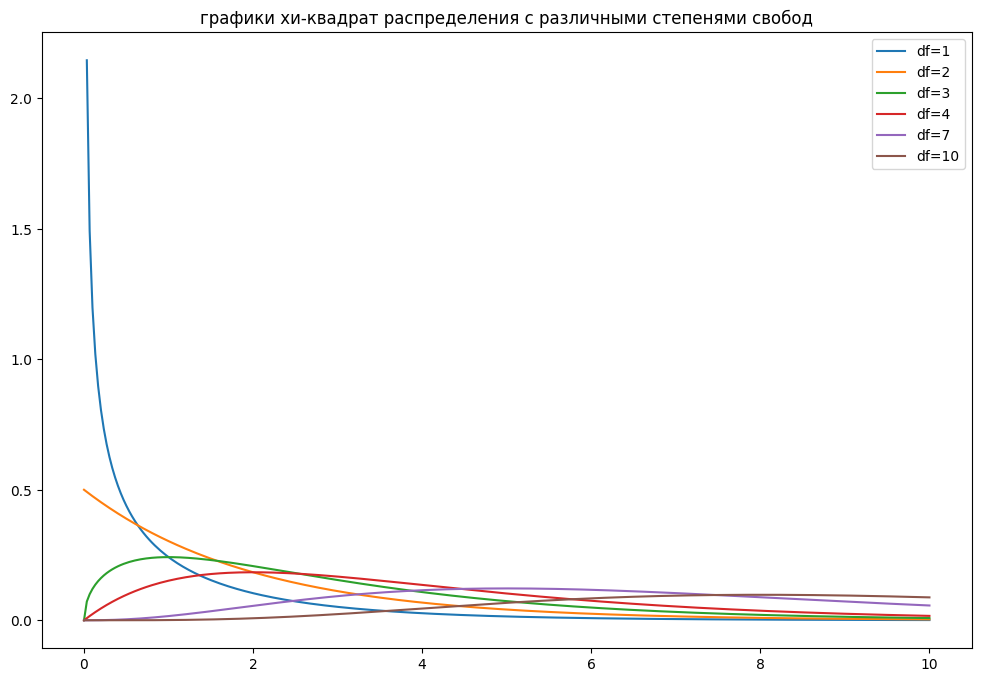

In [55]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,8)

x = np.linspace(0, 10, 300)
# степеня свободы
df_set = {1, 2, 3, 4, 7, 10}
for df in df_set:
    y = chi2.pdf(x, df=df)
    plt.plot(x, y, label=f'df={df}')

plt.title('графики хи-квадрат распределения с различными степенями свобод')
plt.legend()
plt.show()

In [51]:
import plotly.graph_objects as go
import numpy as np
from scipy.stats import chi2

df_list = [1, 2, 3, 4, 7, 10, 50, 100]
chi_squared = np.linspace(0, 100, 1000)
fig = go.Figure()
for df in df_list:
    y = chi2.pdf(chi_squared, df=df)
    fig.add_trace(go.Scatter(x=chi_squared, y=y, name=f'df={df}'))
fig.update_layout(title='графики хи-квадрат распределения с различными степенями свобод', template='plotly_dark')
fig.show()  


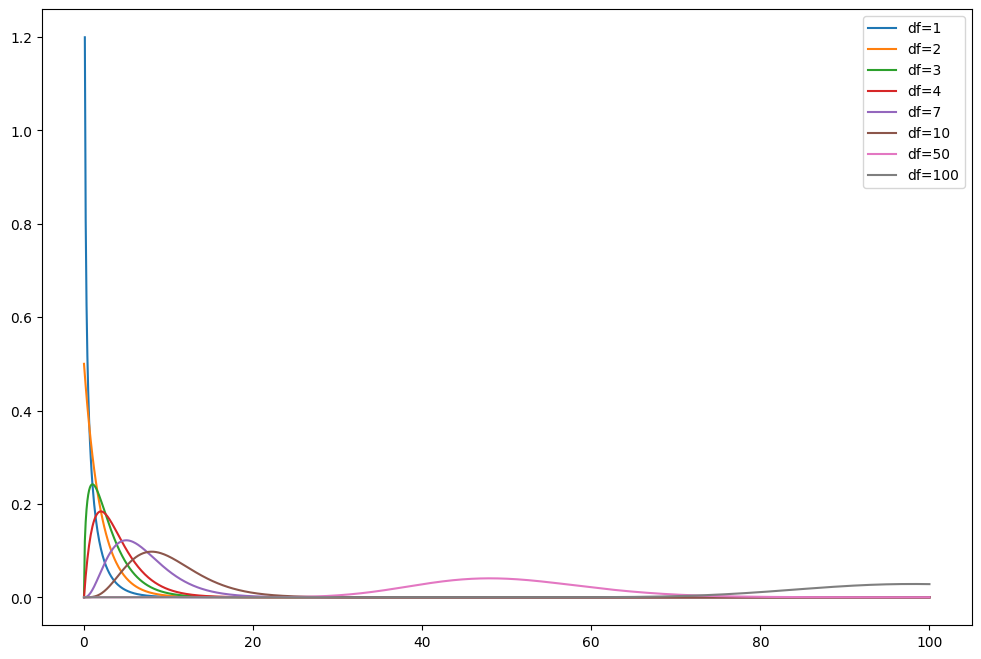

In [53]:
import seaborn as sns
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

df_list = [1, 2, 3, 4, 7, 10, 50, 100]
chi_squared = np.linspace(0, 100, 1000)
for df in df_list:
    y = chi2.pdf(chi_squared, df=df)
    sns.lineplot(x=chi_squared, y=y, label=f'df={df}')
plt.show()


Давайте вспомним как рассчитывается значение статистики в тесте Стьюдента (на примере одновыборочного теста):
$$ t = \frac{\bar{x}-\mu}{\frac{s}{\sqrt{n}}} $$
В знаменателе у нас находится стандартная ошибка, которая представляет собой выборочное стандартное отклонение, делённое на  корень из объёма выборки. В расчёт стандартного отклонения входит сумма квадратов отклонений наблюдаемых значений от их среднего значения - то есть сумма нескольких случайных положительных величин. А из предыдущих степов мы знаем, что сумма квадратов n случайных положительных величин может быть описана при помощи распределения хи-квадрат с n-1 степеням свободы! Так как зная выборочное среднее и n-1 элементов выборки мы всегда можем точно задать последний элемент! Получается, в знаменателе t-статистики у нас спрятано распределение хи-квадрат, для которого нам и нужно знать количество степеней свободы! Таким образом, степени свободы в T-распределении на самом деле берутся из распределения хи-квадрат, которое спрятано в формуле T-статистики.

Давайте теперь вспомним формулу F-статистики, которая является главным показателем дисперсионного анализа: 

<img src="img/F-stat.png" width=400>

В числителе находится сумма квадратов отклонений групповых средних от общего среднего. В знаменателе у нас сумма квадратов отклонений наблюдений от внутригрупповых средних. Таким образом, у нас опять две величины, складывающиеся из квадратов независимых положительных случайных величин. Высчитывая F-значение, мы делим одну величину, имеющую распределение хи-квадрат, на другую величину, имеющую распределение хи-квадрат. Каждой из них соответствует своё количество степеней свободы. Получается, что распределение F-статистики будет характеризоваться двумя параметрами - степенями свободы для двух распределений хи-квадрат!

$$ \chi^2 = (\Omega_1)^2 + (\Omega_2)^2 + ... + (\Omega_n)^2 $$
$$ df = n -1 $$

$ n $ - число градаций нашего фактора

У нас переменные независимые (это одно из условий для применения критерия), то есть результат выпадения орла или решки во время эксперимента не зависит ни от предыдущего результата, ни от других причин.

Просто с точки зрения df (степеней свободы), зная общее количество бросков и количество выпадений одной градации, можно вычислить другую. Но это пост фактум, после реализации эксперимента. (очевидно, что во время эксперимента определить конечный результат невозможно).

<img src='img/Screenshot from 2023-09-10 12-20-26.png' width=500>

статья на хабре про [степени свободы](https://habr.com/ru/companies/stepic/articles/311354/).

## Расчет p-уровня значимости

<img src='img/Screenshot from 2023-09-10 13-41-31.png' width=800>

В данном случае (подбрасывание монетки) мы видим, что первая колонка всегда задает значение второй, то есть если мы знаем количество решек и количество подбрасываний, то можем точно сказать какоее значение находится во второй колонке:

Допустим, N=60

|Решка|Орел|
|:---:|:--:|
|$ \frac{10-30}{\sqrt{30}}=\frac{-20}{\sqrt{30}} $|$ \frac{50-30}{\sqrt{30}}=\frac{20}{\sqrt{30}} $|
|$ \frac{40-30}{\sqrt{30}}=\frac{10}{\sqrt{30}} $|$ \frac{20-30}{\sqrt{30}}=\frac{-10}{\sqrt{30}} $|
|0|0|

Тогда отображая их на графике (сверху), мы получим прямую линию. Только вдоль линии мы можем перемещаться (получать значение $\chi^2$).

<img src='img/Screenshot from 2023-09-10 13-52-20.png' width=1000>

<img src='img/Screenshot from 2023-09-10 13-53-45.png' width=1000>

В итоге мы тестируем гипотезу о том, что распределение частот некоторого признака отличается от заданного теоретического распределения (чаще всего, равномерного).

 Для начала мы просто вывели меру того, насколько сильно это расхождение ($\chi^2$), выяснили, какое у него распределение, которое зависит от количества степеней свободы (n-1, n - число градаций фактора).

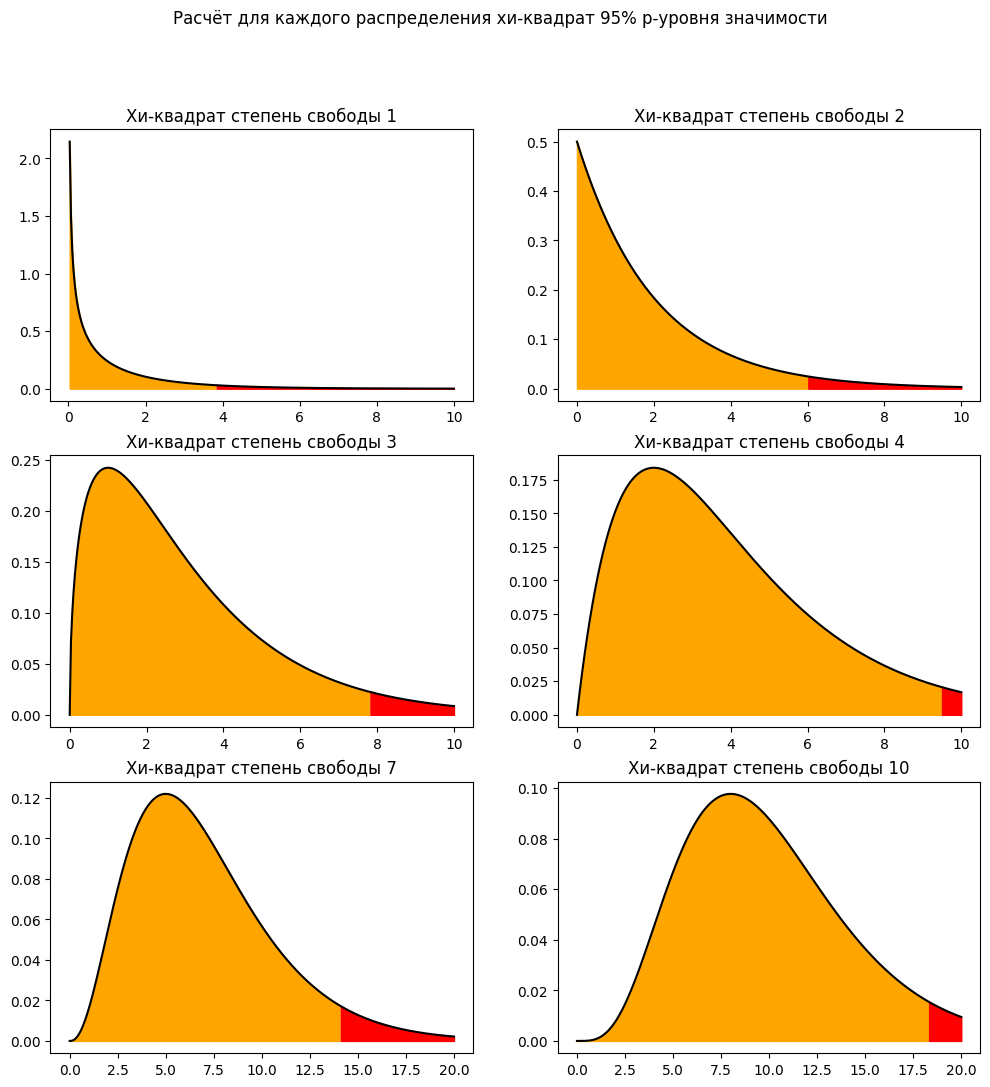

In [5]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 12)

p = 0.95
x1 = np.linspace(0, 10, 300)
x2 = np.linspace(0, 20, 300)
df_set = [1, 2, 3, 4, 7, 10]

fig, axs = plt.subplots(nrows=3, ncols=2)
axs = axs.flat

for i, df in enumerate(df_set):
    chi_value = chi2.isf(1 - p, df=df)
    x = x1 if df <= 4 else x2
    y = chi2.pdf(x, df=df)

    axs[i].set_title(f"Хи-квадрат степень свободы {df}")
    axs[i].plot(x, y, color="k")
    left_x, right_x = x <= chi_value, x >= chi_value
    axs[i].fill_between(x[left_x], y[left_x], color="orange")
    axs[i].fill_between(x[right_x], y[right_x], color="red")


fig.suptitle("Расчёт для каждого распределения хи-квадрат 95% p-уровня значимости")
plt.show()

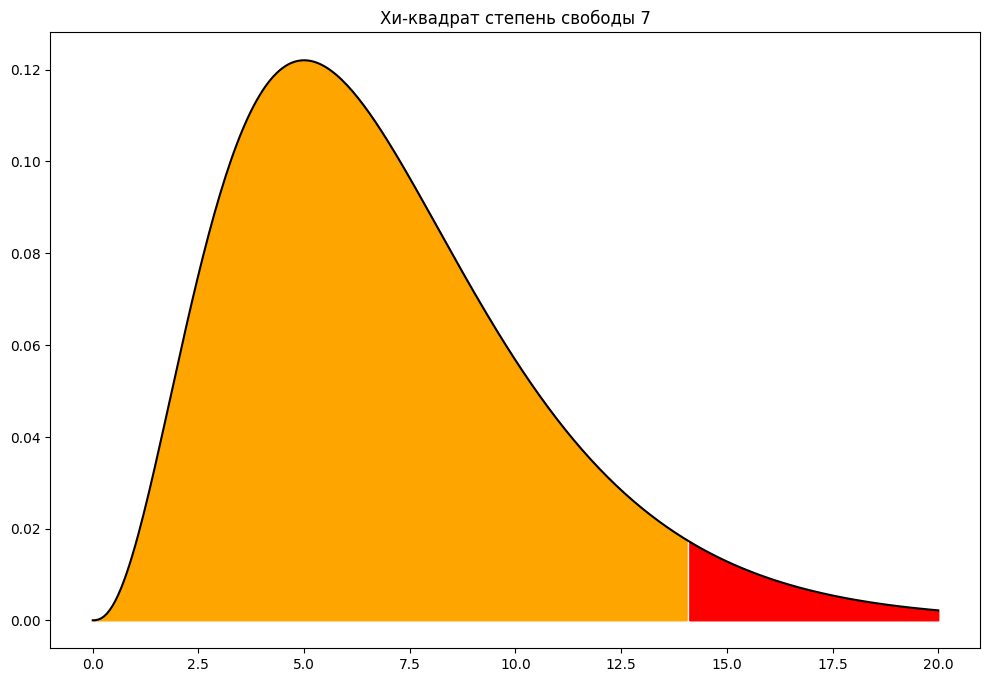

In [4]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

fig = plt.subplot()
p = 0.95
x = np.linspace(0, 20, 300)
df = 7
chi_value = chi2.isf(1-p, df=df)
y = chi2.pdf(x, df=df)

fig.set_title(f'Хи-квадрат степень свободы {df}')
fig.plot(x, y, color='k')
left_x, right_x = x <= chi_value, x >= chi_value
fig.fill_between(x[left_x], y[left_x], color='orange')
fig.fill_between(x[right_x], y[right_x], color='red')


# fig.suptitle('Расчёт для каждого распределения хи-квадрат 95% p-уровня значимости')
plt.show()

In [6]:
from scipy.stats import chi2
import numpy as np
import plotly.graph_objects as go

fig = go.Figure()

p = 0.95
x = np.linspace(0, 20, 1000)
df = 7

chi_value = chi2.isf(1-p, df=df)
y = chi2.pdf(x, df=df)
left_x, right_x = x <= chi_value, x >= chi_value # -> bool
fig.add_traces([go.Scatter(x=x[left_x], y=y[left_x], fill='tozeroy'), go.Scatter(x=x[right_x], y=y[right_x], fill='tozeroy')])
fig.update_layout(title='Расчёт для распределения хи-квадрат c df=7 95% p-уровня значимости', showlegend=False)
fig.show()


1. Высчитали наблюдаемые частоты,
2. предположили, что априорное распределение равномерное,
3. вычислили ожидаемые частоты,
4. посчитали хи-квадрат,
5. проверили р-уровень по распределению хи-квадрат с df=n-1, где n - число градаций номинативного признака.

### Примеры.1.4
Какая доля наблюдений лежит в диапазоне от 2 до 4 у распределения хи-квадрат с двумя степенями свободы?

In probability theory and statistics, the cumulative distribution function (CDF) of a real-valued random variable X, or just distribution function of X, evaluated at x, is the probability that X will take a value less than or equal to x.

In [7]:
"Какая доля наблюдений лежит в диапазоне от 2 до 4 у распределения хи-квадрат с двумя степенями свободы?"
from scipy.stats import chi2

print(round(chi2.cdf(4, df=2), 4))
print(round(chi2.cdf(2, df=2), 4))
print(round(chi2.cdf(4, df=2) - chi2.cdf(2, df=2), 4))

0.8647
0.6321
0.2325


In [26]:
"Какая доля наблюдений лежит в диапазоне от 2 до 4 у распределения хи-квадрат с двумя степенями свободы?"
from scipy.stats import chi2

print(f'{chi2.cdf(4, df=2) - chi2.cdf(2, df=2):.4f}')

0.2325


In [121]:
"Какая доля наблюдений лежит в диапазоне от 2 до 4 у распределения хи-квадрат с двумя степенями свободы?"
from scipy.stats import chi2

print(f'{chi2.sf(2, df=2) - chi2.sf(4, df=2):.4f}')

0.2325


In [2]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2
import numpy as np

# cdf
x = np.linspace(0, 6, 1000)
y = chi2.pdf(x, df=2)
left_2, left_4 = x <= 2, x <= 4
fig = make_subplots(rows=1, cols=2, subplot_titles=("Логика решения через cdf", "Логика решения через sf"))
fig.add_trace(go.Scatter(x=x[left_4], y=y[left_4], fill='tozeroy'), row=1, col=1)
fig.add_trace(go.Scatter(x=x[left_2], y=y[left_2], fill='tozeroy'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y, fill='none'), row=1, col=1)

# sf
left_2, left_4 = x >= 2, x >= 4
fig.add_trace(go.Scatter(x=x[left_2], y=y[left_2], fill='tozeroy'), row=1, col=2)
fig.add_trace(go.Scatter(x=x[left_4], y=y[left_4], fill='tozeroy'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y, fill='none'), row=1, col=2)

fig.show()

Теперь рассчитаем p-уровень значимости для нашего примера с игральной костью. Напомню, что мы получили следующие значения наблюдаемых частот (от единички до шестерки):

10, 10, 10, 5, 10, 15

Проверьте нулевую гипотезу о том, что эмпирическое распределение частот не отличается от равномерного. В поле для ответа введите получившийся p-уровень значимости. 

In [142]:
from scipy.stats import chi2
import numpy as np
import plotly.graph_objects as go

observed = np.array([10, 10, 10, 5, 10, 15])
def chi_value(observed):
    # e - expected
    e = np.mean(observed)
    return sum([((o - e)**2)/e for o in observed])
p = chi2.sf(chi_value(observed), df=(observed.size-1))
print(f'chi2:{chi_value(observed):.4f}')
print(f'p:{p:.4f}')

# визуализцаия
x = np.linspace(0, 15, 1000)
y = chi2.pdf(x, df=(observed.size-1))
rigth_x = x >= chi_value(observed)
fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y))
fig.add_trace(go.Scatter(x=x[rigth_x], y=y[rigth_x], fill='tozeroy'))
fig.update_layout(title=f'p={p:.4f}, chi2={chi_value(observed)}')
fig.show()

chi2:5.0000
p:0.4159


Вернемся к нашему примеру с политическими партиями! Проверьте гипотезу о том, что в ГС нет никаких различий в предпочтениях трех партий. Введите в поле для ответа получившееся значение статистики хи-квадрат с точностью хотя бы до одной цифры после запятой.

<img src="img/партии.png" width=900>

In [2]:
from scipy.stats import chi2
import numpy as np

observed = np.array([10, 30, 50])

def chi_value(observed):
    e = np.mean(observed)  # expected
    x = sum([(o - e) ** 2 / e for o in observed])
    return x
x = chi_value(observed)
p = chi2.sf(x, df = observed.size - 1)
print(f'x = {x:.1f}')
print(f'p = {p:.4f}')

x = 26.7
p = 0.0000


Недавно я пришел на лекцию в Институт биоинформатики и обнаружил, что в группе различное число студентов женского и мужского пола: 15 юношей и 9 девушек. Возможно, кого-то это и могло бы оставить равнодушным, а я вот сразу взял лист бумаги и ручку, чтобы проверить гипотезу о том, что распределение частот девушек и юношей не отличается от равномерного в генеральной совокупности биоинформатиков!

Давайте сверим наши результаты. Введите в поле для ответа получившийся у вас p-уровень значимости.

In [149]:
observed = np.array([15, 9])
p = chi2.sf(chi_value(observed), df=observed.size-1)
print(f'{p:.4f}')

0.2207


In [150]:
observed = [15, 9]
e = sum(observed) / len(observed)
x = sum([(o - e) ** 2 / e for o in observed])
print(round(chi2.sf(x, df=len(observed) - 1), 4))

0.2207


В 2013 году Эдвард Сноуден передал СМИ секретную информацию АНБ, касающуюся слежки американских спецслужб за информационными коммуникациями между гражданами. Однако ﻿его поступок вызвал неоднозначную реакцию в обществе. Исследовательский центр USA TODAY провел опрос 1500 граждан США с целью выяснить, воспринимают ли они поступок Сноудена как положительный или отрицательный. 53% опрошенных респондентов оценили разоблачение положительно.

При помощи теста хи-квадрат проверьте нулевую гипотезу о том, что в генеральной совокупности распределение отношения к поступку Сноудена является равномерным, то есть 50 на 50.

In [3]:
n=1500
observed = np.array([0.53*n, 0.47*n], dtype='int32')
p = chi2.sf(chi_value(observed), df=observed.size-1)
print(f'{p:.4f}')

0.0201


## Анализ таблиц сопряженности

Как при помощи критерия $\chi^2$ можно проверять гипотезу о взаимосвязи двух номинативных переменных.

| |Юноши|Девушки|
|:-:|:-:|:-:|
|Биологи|15|9|
|Информатики|11|6|

Две номинативные переменные пол и профессия, обе с двумя градациями.

Нулевая гипотеза - распределение не отличается от ожидаемого (то есть две переменные не взаимосвязаны между собой).

Альтернативная гипотеза - распределение отличается или иными словами: две переменные взаимосвязаны между собой.

1. Как бы заполнилась эта таблица, если была бы верна нулевая гипотеза и две переменные никак не взаимосвязаны между собой, какие были бы ожидаемые значения в каждой из ячеек?
2. Теперь посмотрим, как он заполнилась в нашем случае, какие наблюдаемые значения в каждой из ячеек?
3. Как рассчитать расстояние между наблюдаемыми и ожидаемыми частотами? ($\frac{o - e}{\sqrt{e}}$)

То есть по сути мы для этой таблички рассчитаем значение хи-квадрат.

**Расчет ожидаемых значений**

Наблюдаемые частоты:

| |Юноши|Девушки|Всего|
|:-:|:-:|:-:|:-:|
|Биологи|15|9|24|
|Информатики|11|6|17|
|Всего|26|15|41|

H0: переменная пол и переменная профессия никак не взаимосвязаны между собой.

Просто равномерное заполнение нашей таблицы не всегда будет правильным решением. Предположим, что в нашей выборке существует дисбаланс классов (например, только 30% девушек) и у нас есть какая-то другая переменная, которая делит переменные на группы - это профессия.

Так вот, тот факт, что переменные не взаимосвязаны между собой, надо интерпретировать следующим образом:

распределение соотношения мужчин и женщим будет совершенно одинаковым как на градации биологи, так и на градации информатики.

У нас будет 30 процентов девушек и 70 процентов мужчин в градации биологи и в градации информатики.

Юношей 26 из 41 - 63.4%,
Девушек 15 из 41.

Примем нулевую гипотезу, что профессия никак не связана с полом, тогда юноши с равной частотой должны наблюдать у биологов и у информатиков.

63.4% от 24 и 17 составляют 15.2 и 10.8 соответственно.

36.6% от 24 и 17 составляют 8.8 и 6.2 соответственно.

То есть мы ожидаем, что распределение пола будет одинаковым как у информатиков, так и у биологов, то есть пол никак не связан с профессией.

ожидаемые частоты:

| |Юноши|Девушки|Всего|
|:-:|:-:|:-:|:-:|
|Биологи|15.2|8.8|24|
|Информатики|10.8|6.2|17|
|Всего|26|15|41|

Но можно было заполнить эту таблицу более простым способом (например):
$$f_{ij}=\frac{f_i*f_j}{N}=\frac{15*24}{41}=8.8.$$

- $f_i$​−число наблюдений в i−ой строке,
- $f_j$​−число наблюдений в j−ом столбце,
- $N$−общее количество наблюдений в таблице. 

Теперь у нас есть ожидаемые и наблюдаемые частоты.

Давайте предположим, что будет, если мы будем многократно повторять нащ эксперимет при условии, что верна нулевая гипотеза. Каждый раз набирать 41 человека, смотреть, сколько там юношей и девушек, сколько биологов и информатиков и строить такую таблицу сопряженностей.

Очевидно, что в каждой из ячеек мы тудем получать какое-то новое эмпирическое наблюдение, и эти наблюдения будут отклоняться от предсказанных значений. Отсюда мы уже можем посчитать значение хи-квадрат.

**Пример.**

В таблице представлены результаты эксперимента, направленного на проверку гипотезы о взаимосвязи двух номинативных переменных с двумя градациями. Рассчитайте ожидаемые частоты для проверки нулевой гипотезы о независимости двух переменных X и Y.

| |Первая градация фактора Х|Вторая градация фактора Х|
|:-:|:-:|:-:|
|Первая градация фактора У|10|6|
|Вторая градация фактора У|5|15|


| |Первая градация фактора Х|Вторая градация фактора Х|Всего|
|:-:|:-:|:-:|:-:|
|Первая градация фактора У|10|6|16|
|Вторая градация фактора У|5|15|20|
|Всего|15|21|36|

In [10]:
round(15 / 36 * 16, 1)

6.7

In [12]:
round(21 / 36 * 16, 1)

9.3

In [13]:
round(15 / 36 * 20, 1)

8.3

In [14]:
round(21 / 36 * 20, 1)

11.7

Тогда ожидаемые значения будут равны:

| |Первая градация фактора Х|Вторая градация фактора Х|Всего|
|:-:|:-:|:-:|:-:|
|Первая градация фактора У|6.7|9.3|16|
|Вторая градация фактора У|8.3|11.7|20|
|Всего|15|21|36|

**Вернемся к примеру с профессиями и полом**

Наблюдаемые частоты:

| |Юноши|Девушки|Всего|
|:-:|:-:|:-:|:-:|
|Биологи|15|9|24|
|Информатики|11|6|17|
|Всего|26|15|41|

ожидаемые частоты:

| |Юноши|Девушки|Всего|
|:-:|:-:|:-:|:-:|
|Биологи|15.2|8.8|24|
|Информатики|10.8|6.2|17|
|Всего|26|15|41|

Посчитаем значение хи-квадрат

In [16]:
chi_value = (15 - 15.2) ** 2 / 15.2 + (9 - 8.8) ** 2 / 8.8 + (11 - 10.8) ** 2 / 10.8 + (6 - 6.2) ** 2 / 6.2
round(chi_value, 2)

0.02

Для расчета статистики хи-квадрат мы использовали разность между наблюдаемыми и ожидаемыми частотами в каждой ячейке, но для того чтобы описать распределение этой статистики, которую мы рассчитали, разумнее весго использовать распределение хи-квадрат только **с одной степенью свободы (df=1)**, потому что из всех четырех ячеек только одна из них независима от других, от остальных трех. Потому что, зная хотя бы одну ячейку и общие значения наблюдений мы всегда можем восстановить всю нашу табличку.

### Поправка Йетса

| |Ю|Д|
|:-:|:-:|:-:|
|Б|15|9|
|И|11|6|

| |Ю|Д|
|:-:|:-:|:-:|
|Б|15.2|8.8|
|И|10.8|6.2|

$$\chi_{Yates}^2=\sum^k{\frac{(|f_0-f_e|-0.5)^2}{f_e}}$$

В теории распределение x2 непрерывно, тогда как вычисляемые значения всегда дискретны, в результате Н0 может отвергаться слишком часто. Чтобы скорректировать значения р уровня - значимости применяется поправка Йетса на непрерывность. Обычно применяется, когда некоторые ожидаемые частоты меньше 10.

**Обычно ее используют только для таблиц 2 на 2.**

$$df=(n-1)*(m-1)=1$$

**Расчет критерия**

In [9]:
chi_value = (abs(15 - 15.2) - 0.5) ** 2 / 15.2 + (abs(11 - 10.8) - 0.5) ** 2 / 10.8 + (abs(9 - 8.8) - 0.5) ** 2 / 8.8 + (abs(6 - 6.2) - 0.5) ** 2 / 6.2
print(chi_value)

0.03899778772444317


In [10]:
# Ну, или более точно:

chi_value = (abs(15 - 15.2195122) - 0.5) ** 2 / 15.2195122 + (abs(11 - 10.7804878) - 0.5) ** 2 / 10.7804878 + (abs(9 - 8.7804878) - 0.5) ** 2 / 8.7804878 + (abs(6 - 6.2195122) - 0.5) ** 2 / 6.2195122
print(chi_value)

0.034076481968798505


<font color='red'>Видимо, как-то более хитро работает поправка Йетса!</font>

In [11]:
from scipy import stats

observed_values = [[15, 9], [11, 6]]
chi2, p_value, ddof, expected = stats.chi2_contingency(observed_values)

print(ddof)  # степени свободы
print(expected)  # ожидаемые значения
print(chi2)  # Хи-квадрат

1
[[15.2195122  8.7804878]
 [10.7804878  6.2195122]]
0.0


In [12]:
from scipy import stats

observed_values = [[15, 9], [11, 6]]
chi2, p_value, ddof, expected = stats.chi2_contingency(observed_values, correction=False)

print(ddof)  # степени свободы
print(expected)  # ожидаемые значения
print(chi2)  # Хи-квадрат

1
[[15.2195122  8.7804878]
 [10.7804878  6.2195122]]
0.020871040723981833


contingency - случайность

### Итоги **Критерий $\chi^2-Пирсона$**

 $$\chi^2=\sum{\frac{(O-E)^2}{E}}$$

- Проверяет гипотезу о том, что наблюдаемое распределение номинативной переменной отличается от ожидаемого.
- Для одной номинативной переменной $df=n-1,$ где n-количество столбцов таблицы (кол-во градаций номинативной переменной).
- Для таблиц сопряженности $df=(n-1)*(m-1),$ где n-количество столбцов таблицы, m-количество строк таблицы.

<font color='red'>Требования:</font>

- Все наблюдения независимы.
- Минимальное количество наблюдений в каждой из ячеек должно быть больше 5.

**Важный момент**

Критерий хи-кварат не рассчитывает никакого показателя про отдельно взятую ячейку, то есть на выходе мы получаем одно число (значение хи-квадрат). Это черевато тем, что, если у нас большая таблица сопряженности (3 * 3 или даже 2 * 2) и мы получаем значимый хи-квадрат, мы можем отклонить нулевую гипотезу. Однако мы не знаем, в какой именно из ячеек возникло наиболее сильное отклонение между ожидаемыми и наблюдаемыми частотами (конечно, можно посмотреть в ручную, но это подход не очень). Поэтому мы не можем интерпретировать результат, кроме как отклонить гипотезу о предполагаемом распределении (либо же не отклонять).

**Пример**

Перед знаком стоп некоторые водители останавливаются полностью, другие лишь сбавляют скорость, но некоторые не останавливаются вообще. Важнейший вопрос, есть ли взаимосвязь между полом и стилем вождения автомобиля!  Ниже представлена таблица сопряженности данных исследования, посвященного этому вопросу.

Чему равняется число степеней свободы в нашем случае? Проверьте нулевую гипотезу о взаимосвязи стиля вождения и пола водителя. Введите получившейся p - уровень значимости.

| |Мужчины|Женщины|
|:-:|:-:|:-:|
|Тормозят|20|15|
|Притормаживают|11|12|
|Не тормозят|7|9|

In [8]:
print([
    [round(38 / 74 * 35, 1), round(36 / 74 * 35, 1)],
    [round(38 / 74 * 23, 1), round(36 / 74 * 23, 1)],
    [round(38 / 74 * 16, 1), round(36 / 74 * 16, 1)]
])

[[18.0, 17.0], [11.8, 11.2], [8.2, 7.8]]


Ожидаемые (E):

| |Мужчины|Женщины|Всего|
|:-:|:-:|:-:|:-:|
|Тормозят|18|17|35|
|Притормаживают|11.8|11.2|23|
|Не тормозят|8.2|7.8|16|
|Всего|38|36|74|

Наблюдаемые (O):

| |Мужчины|Женщины|
|:-:|:-:|:-:|
|Тормозят|20|15|
|Притормаживают|11|12|
|Не тормозят|7|9|

In [13]:
chi_value = (20 - 18) ** 2 /18 + (15 - 17) ** 2 / 17 + (11 - 11.8) ** 2 / 11.8 + (12 - 11.2) ** 2 / 11.2 + (7 - 8.2) ** 2 / 8.2 + (9 - 7.8) ** 2 / 7.8
df = (3 - 1) * (2 - 1)
round(chi_value, df)

0.93

In [14]:
from scipy import stats
p = stats.chi2.sf(chi_value, df=df)
print(round(p, 2))

0.63


Либо:

In [15]:
from scipy import stats

observed_values = [[20, 15], [11, 12], [7, 9]]
chi2, p_value, ddof, expected = stats.chi2_contingency(observed_values)

print(round(p_value, 2))
print(ddof)  # степени свободы
print(expected)  # ожидаемые значения
print(chi2)  # Хи-квадрат

0.62
2
[[17.97297297 17.02702703]
 [11.81081081 11.18918919]
 [ 8.21621622  7.78378378]]
0.9544070774762996


**Пример**

Нельзя ли снизить риск тромбоза назначением небольших доз аспирина (160 мг/сут)?


||Есть тромбоз|Нет тромбоза|
|:-:|:-:|:-:|
|Плацебо|18|7|
|Аспирин|6|13|

In [3]:
print([
    [round(24 / 44 * 25, 1), round(20 / 44 * 25, 1)],
    [round(24 / 44 * 19, 1), round(20 / 44 * 19, 1)]
])

[[13.6, 11.4], [10.4, 8.6]]


Наблюдаемые:

||Есть тромбоз|Нет тромбоза|Всего|
|:-:|:-:|:-:|:-:|
|Плацебо|18|7|**25**|
|Аспирин|6|13|**19**|
|**Всего**|**24**|**20**|**44**|

Ожидаемые:

||Есть тромбоз|Нет тромбоза|Всего|
|:-:|:-:|:-:|:-:|
|Плацебо|13.6|11.4|**25**|
|Аспирин|10.4|8.6|**19**|
|**Всего**|**24**|**20**|**44**|

In [15]:
chi_value = (18 - 13.6) ** 2 / 13.6 + (7 - 11.4) ** 2 / 11.4 + (6 - 10.4) ** 2 / 10.4 + (13 - 8.6) ** 2 / 8.6
# chi_value = (18 - 13.63636364) ** 2 / 13.63636364 + (7 - 11.36363636) ** 2 / 11.36363636 + (6 - 10.36363636) ** 2 / 10.36363636 + (13 - 8.63636364) ** 2 / 8.63636364
round(chi_value, 2)

7.23

In [16]:
from scipy import stats
stats.chi2.sf(chi_value, df=1)

0.007151666941203128

Либо:

In [19]:
from scipy import stats

observed_values = [[18, 7], [6, 13]]
chi2, p_value, ddof, expected = stats.chi2_contingency(observed_values) # с поправкой Йетса

print(round(p_value, 3))
print(ddof)  # степени свободы
print(expected)  # ожидаемые значения
print(chi2)  # Хи-квадрат

0.018
1
[[13.63636364 11.36363636]
 [10.36363636  8.63636364]]
5.57719298245614


In [20]:
from scipy import stats

observed_values = [[18, 7], [6, 13]]
chi2, p_value, ddof, expected = stats.chi2_contingency(observed_values, correction=False) # без поправка Йетса

print(round(p_value, 3))
print(ddof)  # степени свободы
print(expected)  # ожидаемые значения
print(chi2)  # Хи-квадрат

0.008
1
[[13.63636364 11.36363636]
 [10.36363636  8.63636364]]
7.114105263157893


**Уточним результаты**

Анализ остатков позволяет выявить, какие именно частоты значимо отклоняются от ожидаемых значений.

Анализ распределения остатков:

<img src='img/Screenshot from 2023-09-13 19-35-12.png' width=750>

Разберемся, как здесь отображены наши данные. Ширина и высота каждого прямоугольника пропорциональны наблюдаемым частотам в соответствующих строках и столбцах. Цвет прямоугольника показывает величину стандартизированного остатка; если она по модулю больше 2, то прямоугольник будет полупрозрачным, если больше 4, то соответствующий прямоугольник будет закрашен.

**Итого:**
- размер прямоугольников  соответствует количеству наблюдений.
- цвет прямоугольников - величине значимости отклонения ожидаемых и наблюдаемых частот в этой ячейке.
- если значения стандартизированных остатков больше 3х, можно считать, что в этой ячейке зафиксированы значимые отклонения.

x-squared = 5.57719298245614
p-value = 0.018195864430772903
df = 1


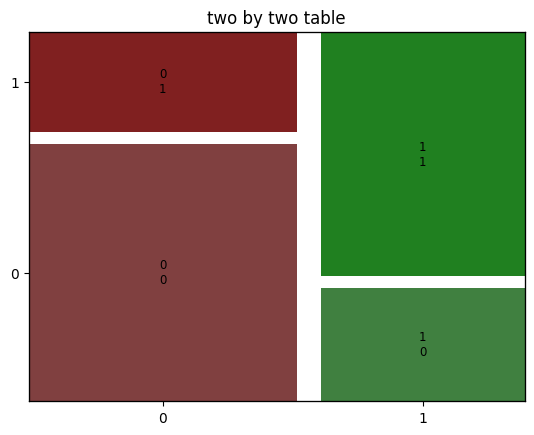

In [23]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

 
observed = np.array([[18, 7], [6, 13]])
chi2, p, df, expected = stats.chi2_contingency(observed)
print('x-squared =', chi2)
print('p-value =', p)
print('df =', df)



mosaic(observed, gap=0.05, title='two by two table')
plt.show()

Thrombosis  No  Yes
Group              
Aspirin     13    6
Placebo      7   18


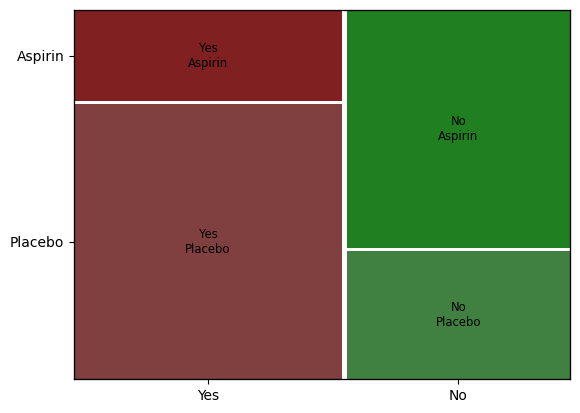

In [22]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import pandas as pd
#воссоздадим таблицу (и подпишем строки и столбцы)
patients = pd.DataFrame({"Thrombosis": ["Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No","No"], "Group": ["Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Placebo","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin","Aspirin"]})
#посмотрим на сводную таблицу пересечения признаков
print(pd.pivot_table(patients, index=["Group"], columns=["Thrombosis"], aggfunc=lambda x: len(x)))
#строим график
mosaic(patients, ["Thrombosis","Group"], gap=0.01)
plt.show()

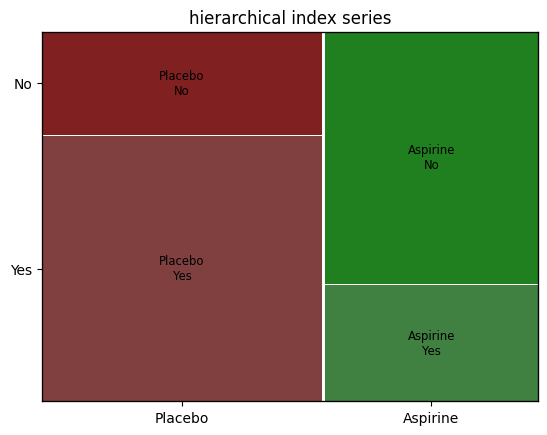

In [25]:
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt

tuples = list(product(['Placebo', 'Aspirine'], ['Yes', 'No']))
index = pd.MultiIndex.from_tuples(tuples)
data = pd.Series([18,7,6,13], index=index)
mosaic(data, title='hierarchical index series')
plt.show()

**Пример**

Обратимся к данным о катастрофе «Титаника». На графике представлена взаимосвязь пола пассажира «Титаника» и того, выжил он или нет в катастрофе. Размеры прямоугольников отвечают за пропорции наблюдений в той или иной ячейке, а цвет прямоугольников — за значение стандартизованного остатка в ячейках. Какие выводы мы можем сделать, проанализировав данный график?

<img src='img/Screenshot from 2023-09-13 19-52-07.png' width=800>

- Значимые отклонения между наблюдаемыми и ожидаемыми результатами получены во всех ячейках, что позволяет говорить: мужчины вероятнее погибнут, чем выживут, а женщины — наоборот.
- На борту Титаника большинство пассажиров - мужчины.
- Есть все основания отклонить нулевую гипотезу об отсутствии взаимосвязи пола и вероятности выжить в катастрофе.

**Пример**

А теперь изучим данные о взаимосвязи шанса выжить в кораблекрушении «Титаника» и класса билета пассажира. В данном случае график стандартизированных остатков построен по результатам таблицы сопряженности 3 на 2.

Какие выводы мы можем сделать в данном случае?

<img src='img/Screenshot from 2023-09-13 19-55-37.png' width=800>


- Пассажиры из третьего класса чаще погибали в катастрофе, чем пассажиры второго класса.
- Для пассажира с билетом первого класса вероятность выжить выше вероятности погибнуть.
- Наши данные не позволяют нам сделать вывод о статистически значимом различии в вероятности выжить или погибнуть у пассажиров второго класса

*Аккуратность — наше все! Небольшое напоминание!*

Я думаю, каждый из вас мог сталкиваться на конференциях, постерах и иногда даже в опубликованных работах с таким описанием результатов: 

Мы проверили гипотезу при помощи критерия хи-квадрат и получили значимые различия (p < 0.05).

В хороших  научных журналах очень большое внимание уделяется корректному представлению результатов статистического анализа. Такая скрупулезность в этом вопросе вовсе не прихоть редакторов. Предположим, другие исследователи захотели сравнить свои результаты с вашими. Могут ли они это сделать, если не знают ни объем вашей выборки, ни число степеней свободы для расчета p-уровня значимости и т. д.?

Есть одно главное требование к оформлению научной работы или исследования: ваши данные должны быть воспроизводимы. И оформление результатов статистического теста не исключение. Всегда указывайте объем выборки, число степеней свободы, значение p-уровня значимости (если это значение может быть записано без сокращения, лучше укажите конкретное число). Оформляйте свои результаты грамотно в любых работах. Это займет у Вас лишние 30 секунд, но сделает вашу работу гораздо понятнее и ценнее в глазах коллег!

## Точный критерий Фишера

Что делать, когда не получается применять критерий Хи-квадрат из-за нарушений некоторых требований к данным. Самое важное требование - **объем выборки**. Но есть точный критерий Фишера, который работает корректно даже на малых выборках.

**Пример:**

||Поправился|Не поправился|Сумма|
|:-:|:-:|:-:|:-:|
|Лекарство № 1|3|1|4|
|Лекарство № 2|1|3|4|
|Сумма|4|4|8|

Можно ли отклонить нулевую гипотезу, что вероятность выздоровления одинакова при использовании первого и при использовании второго лекарства?

А теперь Точный критерий Фишера говорит нам:

"Предположим, у нас есть восемь пациетов, и верна нулевая гипотеза, то есть нет никакой взаимосвязи между вероятностью выздоровления и тем типом лекарств, который человек использовал. Тогда, какова вероятность, если мы выберем случайно четырех человек из лекарства номер 1 и получим, что у них трое поправилось, а один не поправился, и выберем случайно 4 человека использовавшиз лекарство 2 и получим обратную картинку: 3 не поправилось, 1 - поправился. Иными словами мы можем **просто рассчитать вероятность получить конкретно такую таблицу с данными** при условии, что верна нулевая гипотеза. Но это мы рассчитаем только данный кейс, нас же интересую такуе или более сильно выраженные различия (например, 4 и 0, 0 и 4). И для такой табличны мы тоже можем рассчитать искомую вероятность."

**То есть мы считаем вероятность получить конкретной таблички при условии, что верна нулевая гипотеза.** То есть с какой вероятностью мы случайно бы заполнили табличку с такими значеними, если действительно никакой взаимосвязи между типом лекарства и результатом лечения не существует.

Поэтому точный критерий Фишера довольно хорошо справляется с маленькими выборками, потому что решает поставленную задачу своего рода в ручную. Мы просто при помощи комбинаторики смотрим вероятность получения тех или иных данных, складываем вероятности получить наши данные и еще более выраженные значения и тем самым получаем p-уровень значимости.

Однако можно и на больших выборках применять точный критерий Фишера.

**<font color="green">Разберемся, как работает точный критерий Фишера</font>**

||<font color='green'>Поправился +</font>|<font color='red'>Не поправился -</font>|Сумма|
|:-:|:-:|:-:|:-:|
|Лекарство № 1|a|b|a+b|
|Лекарство № 2|c|d|c+d|
|Сумма|a+c|b+d|n|

Допустим, что верна нулевая гипотеза:

Н0: р1=р2=р (например, 0.5).

- х - количество положительных исходов у пациентов, которые использовали лекартсво номер 1.
- у - количество положительных исходов у пациетов, которые использовали лекартсво номер 2.

- x ~ binomial(a+b, p) - количество положительный исходов по лекарству №1
- y ~ binomial(c+d, p) - количество положительный исходов по лекарству №2
- x+y ~ binomial(n, p) - общее количество положительный исходов по нашей выборке

- p(x=a) = $C_{a+b}^a*p^a*(1-p)^{b}$  (с какой вероятностью мы получим а положительных исходов для лекартсва номер 1, если у нас всего было a+b попыток)
- p(y=c) = $C_{c+d}^c*p^c*(1-p)^{d}$
- p(x+y=a+c) = $C_{n}^{a+c}*p^{a+c}*(1-p)^{b+d}$

По формуле условной вероятности:

$$p(x=a|x+y=a+c) = \frac{p(x=a, x+y=a+c)}{p(x+y=a+c)}=\frac{p(x=a)*p(y=c)}{p(x+y=a+c)}$$

* *| - означает "при условии".*
* $p(x=a, x+y=a+c)$ - вероятность, что у нас наступит одновременно два события;
* $p(x+y=a+c)$ - вероятность, что $x+y=a+c$.

$$ \frac{C_{a+b}^a*p^a*(1-p)^{b} * C_{c+d}^c*p^c*(1-p)^{d}}{C_{n}^{a+c}*p^{a+c}*(1-p)^{b+d}} $$

Сократим формулу:

$$ \frac{C_{a+b}^a*C_{c+d}^c}{C_{n}^{a+c}} $$

$$ \frac{C_{4}^3*C_{4}^1}{C_{8}^{4}} = 0.229 $$

И рассчитаем вероятность получить табличку с данными с более сильновыраженными различиями:

$$ \frac{C_{4}^4*C_{4}^0}{C_{8}^{4}} = 0.014 $$

Рассмотрим теперь два противоположных варианта, которые отклоняются также или сильнее, но в противоположную сторону (так как мы проверяем гипотезу впринципе о взаимосвязи, то есть двунаправленную гипотезу).

Вероятности будут теми же, что мы рассчитали ранее (для гипотезы, что лекарство №1 работает лучше).

Учитываем вероятности для двух гипотез (для лекартсва №1 и №2):

$$(0.229 + 0.014)*2=0.49$$

## Итог по части 1

<font color="red">Подытожим методы анализа номинативных данных, с которыми мы познакомились:</font>

**Критерий хи-квадрат:**

Анализ таблицы сопряженности произвольного размера, где значения ожидаемых и наблюдаемых частот в каждой ячейке больше 10.

**Критерий хи-квадрат с поправкой Йетса:**

Анализ таблицы сопряженности два на два, где значения ожидаемых и наблюдаемых частот в каждой ячейке больше 5, но меньше 10.

**Точный критерий Фишера:**

Анализ таблицы сопряженности, в которой экстремально мало наблюдений, в некоторых ячейках число ожидаемых и наблюдаемых частот может быть меньше пяти.

<hr>

# Часть 2 Логистическая регрессия и непараметрические методы 

## Логистическая регрессия

### Постановка задачи

Когда мы строим уравнение логистической регрессии, у нас в **левой** части находится номинативная переменная с двумя градациями, а в **правой** части может находится линейная комбинация других предикторов, как и в случае обычной линейной регрессии, но **проблема** в том, что в правой части мы можем получить любое число от $-\infty$ до $+\infty$, а в левой части у нас находится **номинативная переменная** с двумя градациями. **Как примерить две эти сущности?**

**Логистическая регрессия** - очень обширный по своим возможностям и мощный метод.

Основная идея заключается в том, что зависимая переменная  - номинативная переменная с двумя градциями, а независимые переменные мог быть как номинативными, так и количественными.

<font color='green'>Мы сделаем акцент на случае, когда все переменные - номинативные.</font>

**Что за ограничения накладываются на метод?** Почему ЗП имеет только две градации? Задача бинарной классификации в статистике возникает очень часто (например, задачи диагностики: спам/не спам, разрешенный багаж/запрещенный багаж).

У нас есть зависимая переменная (получил ли человек сертификат в курсе по статистике или нет), и она имеет две градации (получил/не получил). И мы хотим посмотреть как на эту переменную влияют разные предикторы (разного типа):
- x2 - сколько времени человек провел времени на рок-концертах до экзамена;
- читал ли человек книжки по статистике или не читал (т.е. тоже номинативная переменная с двумя градациями).

И **логика** очень простая:

Мы хотим выразить зависимую переменную через некоторую линейную комбинацию наших предикторов, где коэффициент ($b_k$) перед предикктором будет говорить о степене влияния этой переменной на нашу ЗП:

$$p_i = b_0 + b_1 * x_{1.i} + b_2 * x_{2.i} + .... + b_k * x_{k.i}$$

**Первая проблема**, которая очевидна, наша ЗП - номинативная с 2мя градациями, а линейная комбинация предикторов может выдавать в сумме любое число от $-\infty$ до $+\infty$.
Как приравнять две эти части уравнения?

Так как ЗП имеет две градации, то можно перейти к непрерывному показателю, которые эквивалентем нашей ЗП, а именно **вероятности получения положительного исхода**, но этот показатель *зажат* в диапазоне от 0 до 1. Но с этим не так сложно справится.

Теперь вопрос, как нам примерить вероятность с линейной комбинацией наших признаков?

**Ответ:** <font color='green'>рассчитать натуральный логарифм шансов,</font> который сможет принимать значения от $-\infty$ до $+\infty$.

Для этого часто испольхуют **логит трансформацию**.

**Шанс** - отношение вероятности учпеха (Y=1) к вероятности неудачи (Y=0).

$$odds = \frac{p}{1-p}$$

|<font color='green'>P</font>|<font color='red'>odds</font>|
|:-:|:-:|
|.01|.010101|
|.2|.25|
|.3|.42|
|.4|.67|
|.25|.34|
|.5|1|
|.6|1.5|

<img src='img/odds.png' width=800>

Пример:

- Орел (+): 2 раза,
- Решка (-): 8 раз.

$$p=\frac{2}{2+8}$$
$$odds=\frac{p}{1-p}$$
$$odds=\frac{2}{8}=0.25$$


Шансы никак не ограничены сверху, то есть лежат в промежутке от 0 до $+\infty$.

**Терпеь просто рассчитаем натуральный логарифм от значения шансов:**

|<font color='green'>P</font>|<font color='red'>odds</font>|log odds|
|:-:|:-:|:-:|
|.01|.010101|-4.6|
|.2|.25|-1.38|
|.3|.42|-0.84|
|.4|.67|-0.4|
|.5|1|0|
|.6|1.5|0.4|
|.7|2.34|0.84|
|.8|4|1.38|

Теперь значения меньше 1(odds) будут давать отрицательные значения, а значения больше 1 будут давать положительные значения.

логарифм большой -> шанс большой -> вероятность положитльного исхода большая

C:\Users\ustim\AppData\Local\Temp\ipykernel_12120\3132777126.py:6: RuntimeWarning: divide by zero encountered in divide
  return p/(1-p)
C:\Users\ustim\AppData\Local\Temp\ipykernel_12120\3132777126.py:15: RuntimeWarning: divide by zero encountered in log
  x1 = np.log(odds(p1))


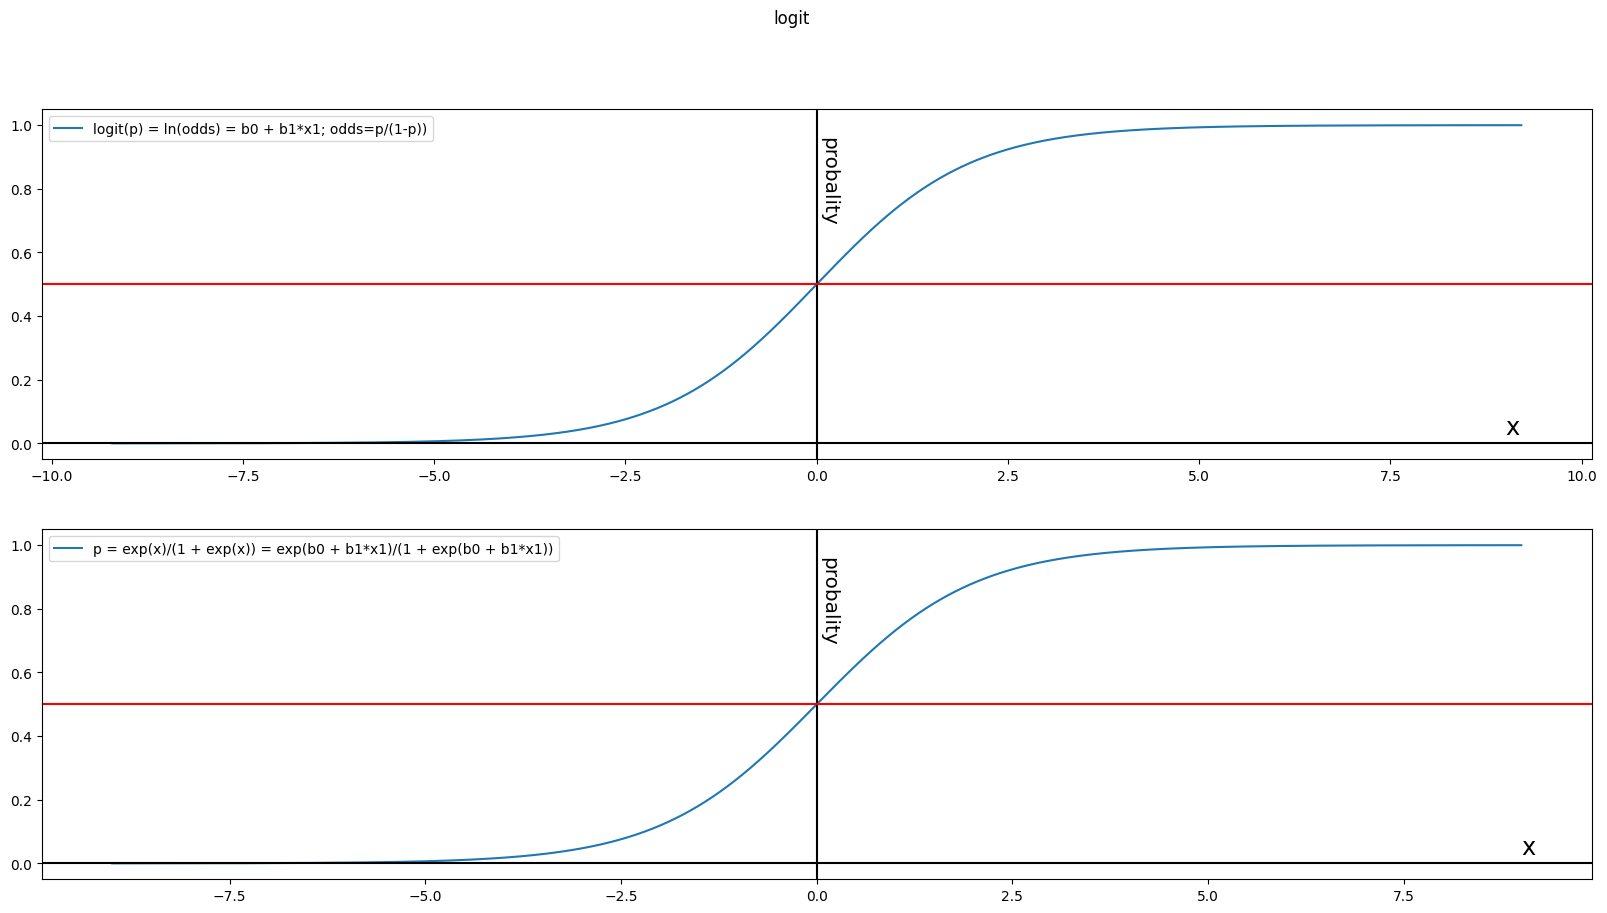

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def odds(p):
    '''Формула выпадения шансов от вероятности'''
    return p/(1-p)

def logit(x):
    '''Формула вероятности от логарифма шанса (логита)'''
    return np.exp(x)/(1 + np.exp(x))

fig, (ax1, ax2) = plt.subplots(2, figsize=(20, 10))

p1 = np.linspace(0, 1, 10000)
x1 = np.log(odds(p1))
x2 = np.linspace(-9, 9, 10000)
p2 = logit(x2)

ax1.plot(x1, p1, label='logit(p) = ln(odds) = b0 + b1*x1; odds=p/(1-p))')
ax2.plot(x2, p2, label='p = exp(x)/(1 + exp(x)) = exp(b0 + b1*x1)/(1 + exp(b0 + b1*x1))')


for ax in (ax1, ax2):
    # создадим оси    
    ax.axvline(0, color='k')
    ax.axhline(0, color='k')
    # подпишем оси
    ax.text(9, 0.03, 'x', size='xx-large')
    ax.text(0.03, 0.7, 'probality', size='x-large', rotation=-90)
    ax.axhline(0.5, color='r')
    ax.legend()
    
fig.suptitle('logit')
plt.show()

$$logit(p)=log(\frac{p}{1-p})=b_0+b_1*x_1$$
$$p=\frac{exp(b_0+b_1*x_1)}{1+exp(b_0+b_1*x_1)}$$

- Значение шансов (odds) не может быть меньше нуля.
- Если натуральный логарифм шансов равен 1000, это означает, что вероятность положительного исхода приблизительно равняется единице.
- Если значение шансов (odds) меньше единицы, это означает, что вероятность положительного исхода меньше 0.5

Предположим, мы подбросили монетку 100 раз, и 70 раз выпал орел. Чему равняется натуральный логарифм шансов выпадения решки?

Чтобы не запутаться, давайте в этом задании рассматривать как "успех" - выпадение решки.

In [3]:
import math
math.log((100-70)/70)

-0.8472978603872037

Предположим, что мы получили логарифм шансов выпадения решки, равный -1. Тогда вероятность выпадения решки равняется:

In [4]:
1/(math.e+1)

0.2689414213699951

In [5]:
math.exp(-1)/(1+math.exp(-1))

0.2689414213699951

Рассчитайте логарифм шанса, того что случайно выбранный человек из нашей выборки окажется биологом.

In [6]:
math.log((15)/11)

0.31015492830383945

Предположим, мы решили построить регрессионную модель, в которой зависимая переменная — номинативная переменная с двумя градациями. Какие утверждения верны?


<font color='green'>В качестве предикторов могут выступать как количественные, так и номинативные переменные.

После преобразования вероятности в логарифм шансов предсказания регрессионной модели могут быть на промежутке от минус</font>


<font color='red'>В качестве предикторов могут выступать только количественные переменные.

В качестве предикторов могут выступать только номинативные переменные.

После преобразования вероятности в логарифм шансов предсказания регрессионной модели могут быть только на промежутке от 0 до 1.

После преобразования вероятности в логарифм шансов предсказания регрессионной модели могут быть только на промежутке от -1 до 1.</font>

## Модель без предикторов. Intercept only model

У нас в левой части уравнения логарифм шансов (количественная переменная), в правой - линейная комбинация предикторов с коэффициентами перед ними. Коэффициенты подбираются методом максимального правдоподобия.

In [1]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
nSurvived = df.groupby('Survived')['Survived'].count()
nSurvived

Survived
0    549
1    342
Name: Survived, dtype: int64

In [9]:
y = df.Survived
# фиктивный предиктор (чтобы сделать модель без предиктора)
X = np.zeros((y.size, 1))

model = LogisticRegression()
clf = model.fit(X, y)
# шансы полученные из модели и вычисленные нами
odds_1 = np.exp(clf.intercept_.item()) # Функция numpy. asscalar() : Эта функция переводит массив из единичного элемента в соответствующий ему тип данных Python
odds_2 = nSurvived[1] / nSurvived[0]
print(
    f"""
odds_1 {odds_1:.4f} (вычисленные)
odds_2 {odds_2:.4f} (полученные)
probability of Survival {(odds_1/(odds_1 + 1)):.4f}
intercept {clf.intercept_.item()}
"""
)


odds_1 0.6231 (вычисленные)
odds_2 0.6230 (полученные)
probability of Survival 0.3839
intercept -0.473056496077335



У нас есть зависимая переменная Survied. Мы хотим построить модель, где Y = одному числу, которое максимально точно описывает, как распределилась наша переменная. То есть можно это представить в таком виде:
$$\log(\frac{p}{1-p})=intercept$$

То есть сейчас intercept - натуральный логприфм шансов положительного исхода по всей нашей выборке.

Чтобы рассчитать шанс положительного исхода нужно рассчитать экспоненту значения intercept.

Такая модель решает задачу, которую мы поставили в самом начале курса:

У нас есть intercept < 0, этот intercept статистически значимо отличается от нуля -> логарифм шансов значимо меньше нуля -> шансы значимо меньше 1 -> вероятность выжить значимо меньше, чем вероятность невыжить.

Предположим, мы много кратно повторяли наше исследование при условии, что равна нулевая гипотеза. И мы смотрим, существует ли разница в вероятности положительного или отрицательного исхода (сущетсвует ли значимое отличие логарифма шансов от 0). Если верна H0, то мы не должны получать очень часто сильные отклонения от предсказанных данных нулевой гипотезой. Если бы мы при этом каждый раз замеряли значение нашего коэффициента (логарифма шансов), то это значение распределилось приблизительно нормальным образом со средним, равным нулю (так как $\log(1)=\log(\frac{0.5}{0.5}=0)$).

### Пример:

Свободный член логистической регрессии без предикторов, равный 0.5, означает, что:

In [12]:
np.exp(0.5)

1.6487212707001282

In [13]:
np.exp(0.5) / (1 + np.exp(0.5))

0.6224593312018546


- ~~Вероятность положительного исхода не отличается от вероятности отрицательного исхода.~~
- ~~Полученные результаты статистически значимы.~~
- Шанс положительного исхода больше единицы.
- ~~Вероятность отрицательного исхода выше вероятности положительного исхода.~~
- Вероятность положительного исхода выше вероятности отрицательного исхода.

### Пример:

P < 0.05 для свободного члена логистической регрессии означает, что:
(укажите верные высказывания)

- Вероятности двух исходов зависимой переменной значимо различаются между собой
- ~~Логарифм шансов значимо больше 1~~
- ~~Погрешность оценки коэффициента очень высокая~~
- Распределение исходов в нашей выборке значимо отличается от равномерного
- ~~Шансы положительного исхода значимо меньше нуля.~~

### Пример:

С помощью логистической регрессии без предикторов мы захотели узнать, правда ли, что сдавая Анатолию Дмитриевичу, легче провалить экзамен, чем сдать. В нашей выборке было 50 студентов. Часть из них сдала экзамен (положительный исход), а часть - нет (отрицательный исход). Свободный член нашей регрессии оказался равен -0.8472979. Сколько человек всё-таки сдало экзамен?

In [14]:
odds = np.exp(-0.8472979)
p = odds / (1 + odds)
n_positive = 50 * p

In [15]:
n_positive

14.999999584065643

## Модель с одним номинативным предиктором

Таблица сопряжённости пола и выживаемости:

In [164]:
SexSurvived = pd.crosstab(df.Survived, df.Sex)
SexSurvived

Sex,female,male
Survived,,
0,81,468
1,233,109


In [172]:
y = df.Survived
# так как там были значения типа string, то надо перевести в номинативный тип
X, _ = pd.factorize(df.Sex)
# convert 1d array to column vector
X = X.reshape((-1, 1))

# penalty - это регулиризация, которая нас, в данный момент, не касается
model = LogisticRegression(penalty='none')
clf = model.fit(X, y)
print(f'''
coef:\t\t{np.asscalar(clf.coef_):.4f}
intercept:\t{np.asscalar(clf.intercept_):.4f}
''')


coef:		2.5137
intercept:	-1.4571



In [170]:
odds_f = SexSurvived['female'][1]/SexSurvived['female'][0]
odds_m = SexSurvived['male'][1]/SexSurvived['male'][0]
odds_fm = odds_f/odds_m
odds_mf = odds_m/odds_f
print(f'''
log(odds_f) = {np.log(odds_f):.4f}
log(odds_m) = {np.log(odds_m):.4f}
log(odds_fm) = {np.log(odds_fm):.4f}
log(odds_mf) = {np.log(odds_mf):.4f}
''')


log(odds_f) = 1.0566
log(odds_m) = -1.4571
log(odds_fm) = 2.5137
log(odds_mf) = -2.5137



В данном случае значение **odds_m** равно значению **intercept** в моделе и значит, что у мужчин было меньше шансов спастись (сексизм, да?!) на титанике.
А значение коэффициента (**coef**) равно отношению шансов спастись женщин, по отношению к мужчин **odds_fm** ( дофига больше шансов было у них:-( )  

## Модель с двумя номинативными предикторами

## Взаимодействие номинативных предикторов

## Когда нужно использовать непараметрические методы и почему?

## Непараметрические методы. Продолжение.

<hr>

# Часть 3 Кластерный анализ и метод главных компонент

## Кластерный анализ методом k-средних

[Сайт для визуализации k-means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

**кратко о k-means**
 - кластерный анализ это метод обучения **без учителя**, в отличие от регрессии
 - количество кластеров задаётся исследователем
 - кластеры задаются с помощью центроидов, которые стремяться в центр каждого кластера, и каждая точка кластера находится наиболее близко к своему центроиду.
 - центроид кластера - аналог центра масс в физике. Или же по аналогии, можно сказать, что центроиды это геометрический центр кластера.

**идея метода**
 - решаем на сколько кластеров будем делить наблюдения
 - случайно выбираем начальные позиции центроидов классов
 - выводим центроиды на наилучшие позиции
 - **Profit**
 
 <img src='img/k-means.gif' width=300/>
 

In [33]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


 - petal - лепесток
 - sepal - чашелистик (один из зеленых листочков, образующих чашечку цветка)

<AxesSubplot:xlabel='sepal length (cm)', ylabel='petal width (cm)'>

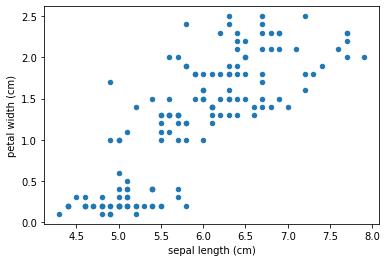

In [7]:
df.plot(kind='scatter', x='sepal length (cm)', y='petal width (cm)')

Можно предположить, о наличие трёх кластеров тут, попробуем определить их методом k-means.

In [21]:
from sklearn.cluster import KMeans

# определим метод
kmeans = KMeans(n_clusters=3)
# вырежем данные, которые нам нужны
data = df.loc[:, ['sepal length (cm)','petal width (cm)']]
# построим модель
model = kmeans.fit(data)
# получим кластеры
data['cluster'] = model.labels_
data.head()

,sepal length (cm),petal width (cm),cluster
0,5.1,0.2,1
1,4.9,0.2,1
2,4.7,0.2,1
3,4.6,0.2,1
4,5.0,0.2,1


<AxesSubplot:xlabel='sepal length (cm)', ylabel='petal width (cm)'>

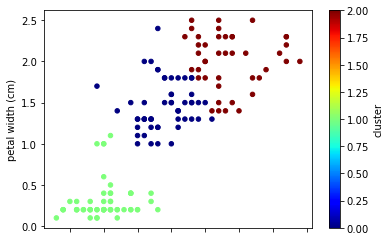

In [31]:
data.plot(kind='scatter', x='sepal length (cm)', y='petal width (cm)', c='cluster', colormap='jet')

Теперь сравним с реальными видами ирисами, и увидем, что кластеры были разделенны довольно корректно.

<AxesSubplot:xlabel='sepal length (cm)', ylabel='petal width (cm)'>

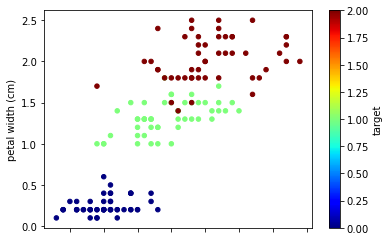

In [34]:
df.plot(kind='scatter', x='sepal length (cm)', y='petal width (cm)', c='target', colormap='jet')

## Может-ли-кластерный-анализ-ошибаться?

## Как определить оптимальное число кластеров?

In [1]:
from pandas import DataFrame
from sklearn.cluster import KMeans

Data = {'x': [-3,1,2,3,5,6,7],
        'y': [3,4,6,8,2,11,1]
       }
  
df = DataFrame(Data,columns=['x','y'])
  
kmeans = KMeans(1)
kmeans.fit(df)
print(kmeans.inertia_)

146.0


## Иерархическая кластеризация

## Введение в метод анализа главных компонент